https://www.kaggle.com/datasets/aadigupta1601/chest-x-ray-pneumonia-numerical-feature-dataset

# Conjunto de dados de características numéricas de pneumonia em radiografias de tórax

**Características numéricas validadas extraídas de imagens de raio-X do tórax**

# Sobre o conjunto de dados

Este conjunto de dados fornece uma representação numérica em estilo radiômico de imagens de raios-X do tórax (pneumonia) .

Cada imagem do conjunto de dados de origem foi convertida em um conjunto estruturado de características numéricas validadas, incluindo estatísticas de intensidade global, descritores de textura (GLCM), características no domínio da frequência (FFT), métricas baseadas em bordas e características de padrão binário local (LBP).

O conjunto de dados destina-se a análises estatísticas, aprendizado de máquina clássico, engenharia de recursos, redução de dimensionalidade e uso educacional, sem exigir processamento direto de imagens ou pipelines de aprendizado profundo.

Todas as características foram calculadas usando um pipeline cuidadosamente validado. Cada grupo de características foi testado individualmente usando métodos de perturbação (por exemplo, desfoque e embaralhamento de pixels) para garantir a correção numérica e um comportamento significativo.

Nenhum modelo de aprendizado de máquina foi treinado durante a criação de recursos.

# Fontes

https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia

# Obs: 

Este arquivo contém características numéricas extraídas da versão de teste do conjunto de dados de imagens de raios-X do tórax (Pneumonia).

Cada linha corresponde a uma imagem de raio-X do tórax do conjunto de teste original e inclui as mesmas características numéricas validadas que os arquivos de treinamento e validação.

Este arquivo destina-se à avaliação final, comparação de desempenho e análise imparcial.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

train = pd.read_csv('train_features.csv')
test = pd.read_csv('test_features.csv')
val = pd.read_csv('val_features.csv')

# EAD

In [2]:
print(train.head())
print(train.info())

       mean       std  min       max    median       p10       p90  skewness  \
0  0.286990  0.149222  0.0  0.996078  0.247059  0.125490  0.533333  0.784317   
1  0.537788  0.261362  0.0  1.000000  0.564706  0.150980  0.862745 -0.390577   
2  0.478816  0.228072  0.0  1.000000  0.537255  0.074510  0.725490 -0.739819   
3  0.556725  0.219356  0.0  1.000000  0.592157  0.258824  0.800000 -0.917178   
4  0.419866  0.231424  0.0  1.000000  0.482353  0.000000  0.670588 -0.671260   

   kurtosis   entropy  ...     lbp_1     lbp_2     lbp_3     lbp_4     lbp_5  \
0 -0.166128  7.043110  ...  0.080826  0.051346  0.091446  0.138184  0.122513   
1 -0.708541  7.704054  ...  0.074219  0.058502  0.095657  0.148499  0.113785   
2 -0.366467  7.294026  ...  0.068634  0.060135  0.101501  0.149643  0.115173   
3  0.403122  7.364598  ...  0.071854  0.057770  0.096863  0.149902  0.121277   
4 -0.759173  6.775589  ...  0.073303  0.049850  0.077972  0.109695  0.093506   

      lbp_6     lbp_7     lbp_8     lb

In [3]:
#Estatística Descritiva
print(train.describe())

              mean          std          min          max       median  \
count  5216.000000  5216.000000  5216.000000  5216.000000  5216.000000   
mean      0.481919     0.222822     0.002022     0.987354     0.522075   
std       0.072694     0.037348     0.013414     0.048650     0.092902   
min       0.237626     0.079597     0.000000     0.596078     0.223529   
25%       0.438359     0.197766     0.000000     1.000000     0.470588   
50%       0.481361     0.224454     0.000000     1.000000     0.525490   
75%       0.526967     0.249546     0.000000     1.000000     0.580392   
max       0.868507     0.342862     0.301961     1.000000     0.886275   

               p10          p90     skewness     kurtosis      entropy  ...  \
count  5216.000000  5216.000000  5216.000000  5216.000000  5216.000000  ...   
mean      0.123173     0.738254    -0.570828    -0.485375     7.276571  ...   
std       0.106454     0.071116     0.407459     0.827220     0.229401  ...   
min       0.00000

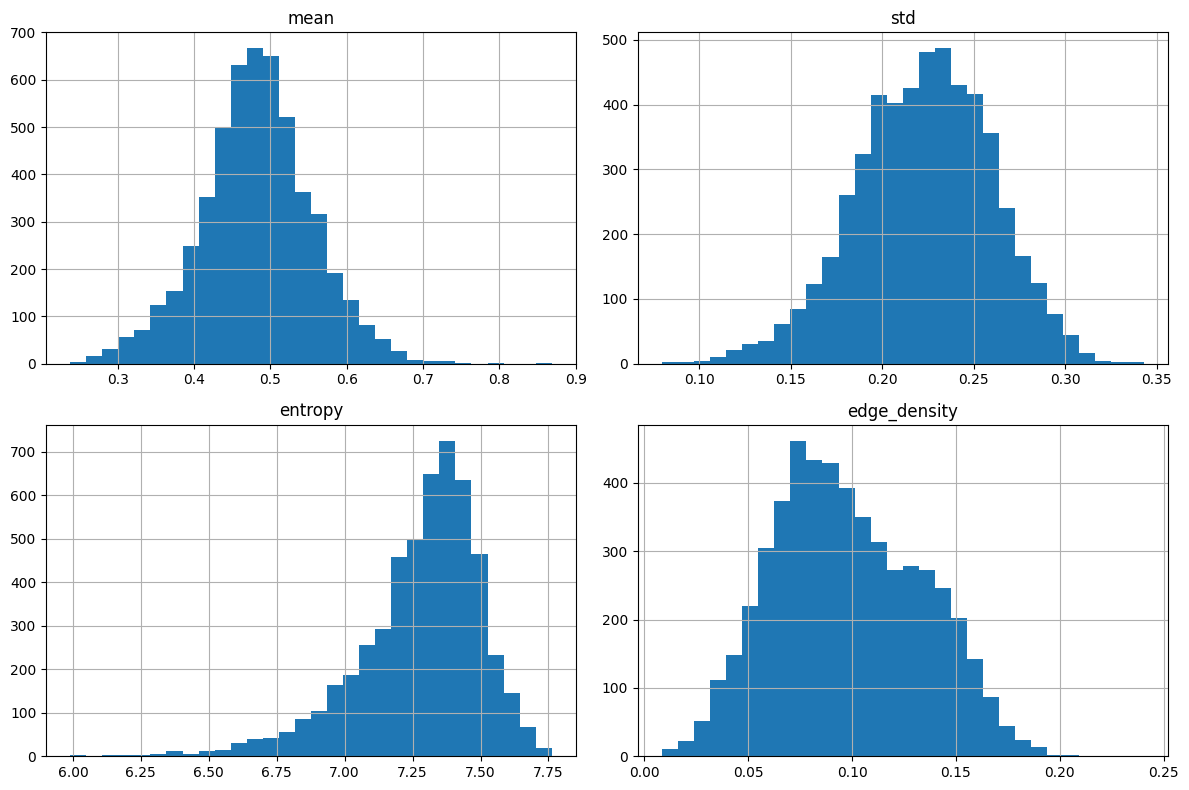

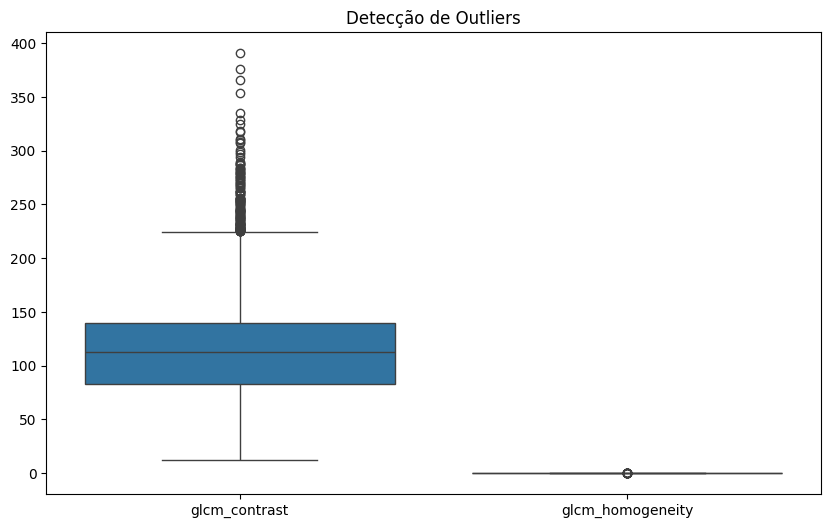

In [4]:
#Visualização de Distribuições
#Histograma de algumas variáveis principais
cols_to_plot = ['mean', 'std', 'entropy', 'edge_density']
train[cols_to_plot].hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()

#Boxplot para identificar outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=train[['glcm_contrast', 'glcm_homogeneity']])
plt.title("Detecção de Outliers")
plt.show()

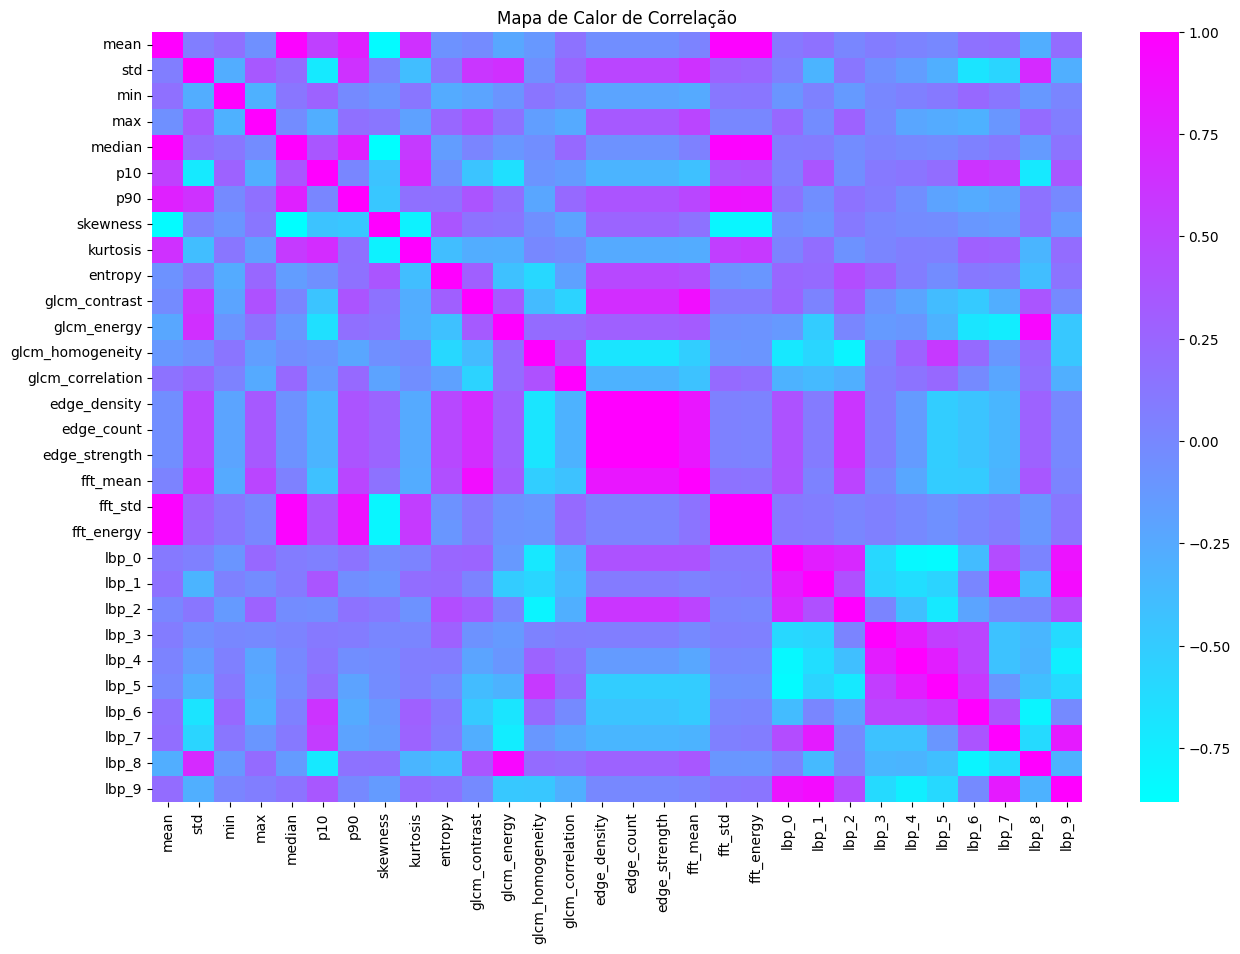

In [5]:
#Análise de Correlação
plt.figure(figsize=(15, 10))
corr = train.drop(columns=['image']).corr() # Removemos a coluna 'image' que é o nome do arquivo
sns.heatmap(corr, annot=False, cmap='cool', fmt=".2f")
plt.title("Mapa de Calor de Correlação")
plt.show()

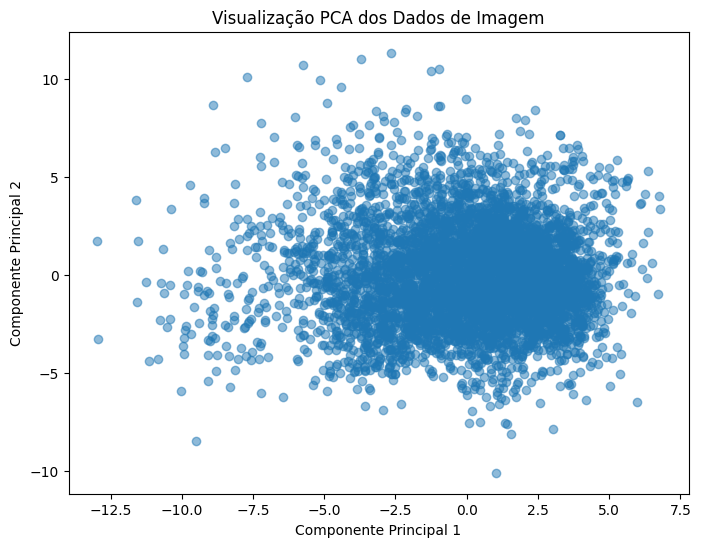

In [6]:
#Análise de Componentes Principais (PCA)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

#Normalizar os dados (essencial para PCA)
features = train.drop(columns=['image'])
x = StandardScaler().fit_transform(features)

#Aplicar PCA para 2 componentes
pca = PCA(n_components=2)
components = pca.fit_transform(x)

plt.figure(figsize=(8, 6))
plt.scatter(components[:, 0], components[:, 1], alpha=0.5)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Visualização PCA dos Dados de Imagem')
plt.show()

# Consolidação EAD

In [7]:
#Consolidação e Limpeza
#Adicionar rótulo de origem antes de concatenar
train['split'] = 'train'
test['split'] = 'test'
val['split'] = 'val'

df = pd.concat([train, test, val], axis=0).reset_index(drop=True)

#Remover coluna de nome de imagem para análise estatística
df_numeric = df.drop(columns=['image', 'split'])

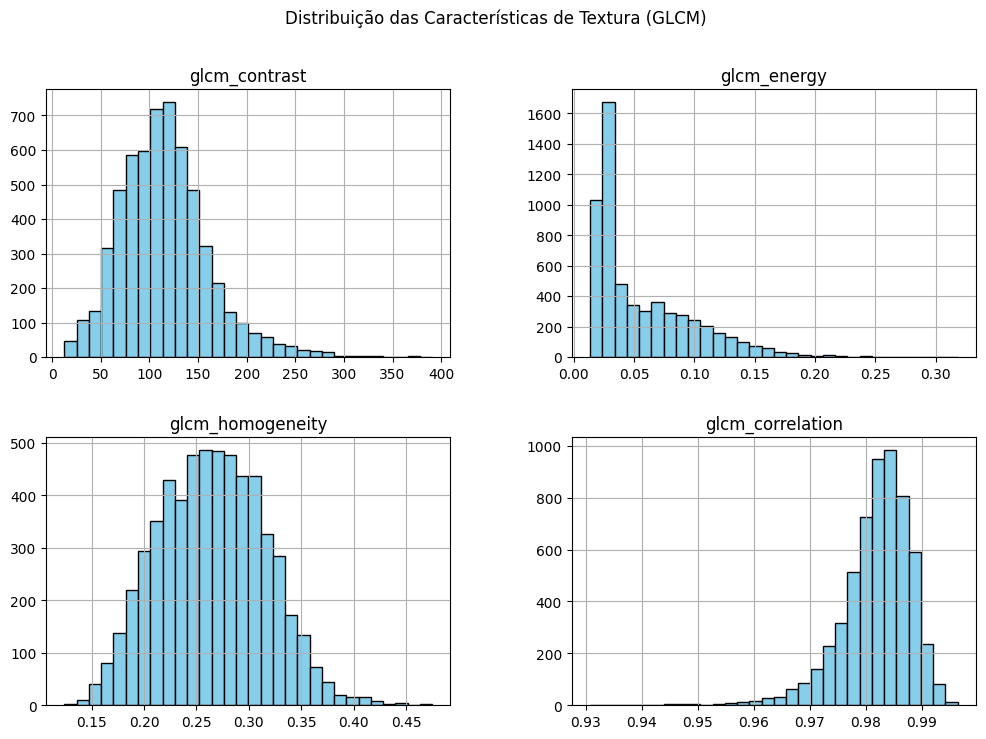

C:\Users\Usuário\AppData\Local\Temp\ipykernel_2164\3083739571.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='split', y='mean', data=df, palette='Set2')


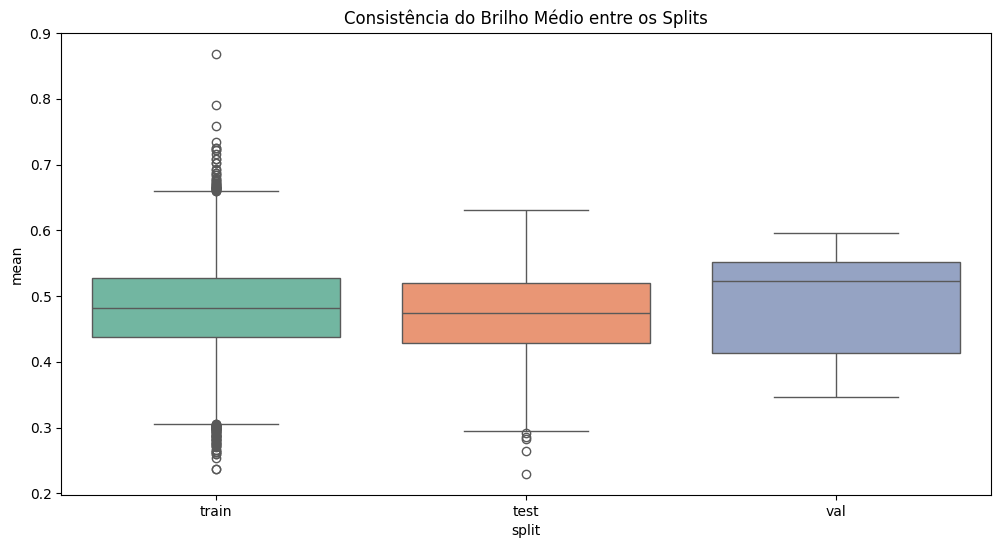

In [8]:
#Análise de Distribuição e Escala
#Histograma das métricas de textura (GLCM)
cols_glcm = ['glcm_contrast', 'glcm_energy', 'glcm_homogeneity', 'glcm_correlation']
df[cols_glcm].hist(figsize=(12, 8), bins=30, color='skyblue', edgecolor='black')
plt.suptitle("Distribuição das Características de Textura (GLCM)")
plt.show()

#Boxplot para comparar as escalas entre os conjuntos (Split)
plt.figure(figsize=(12, 6))
sns.boxplot(x='split', y='mean', data=df, palette='Set2')
plt.title("Consistência do Brilho Médio entre os Splits")
plt.show()

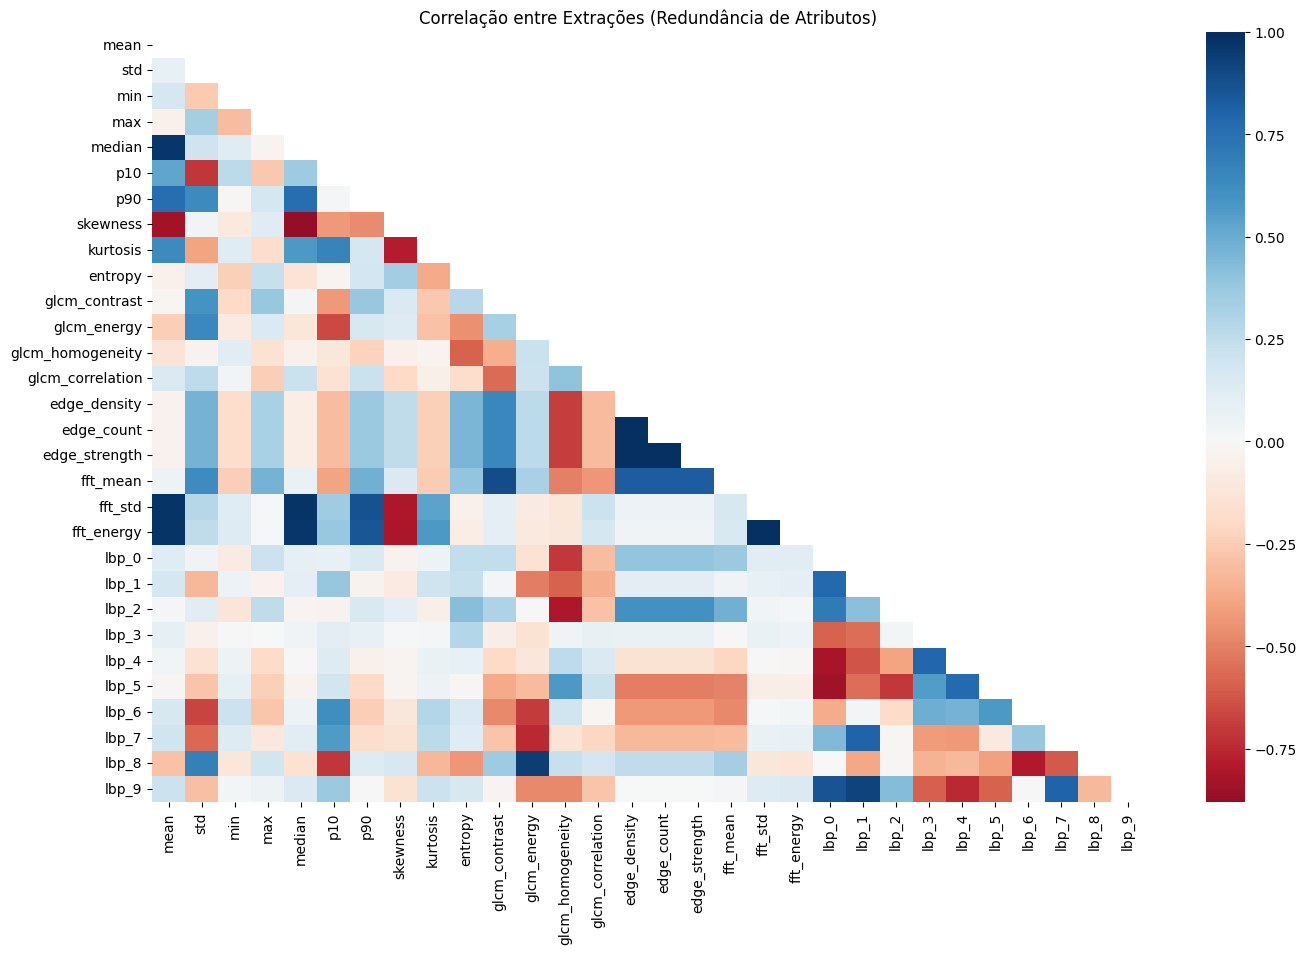

In [9]:
#Seleção de Características: Matriz de Correlação
plt.figure(figsize=(16, 10))
mask = np.triu(np.ones_like(df_numeric.corr(), dtype=bool))
sns.heatmap(df_numeric.corr(), mask=mask, annot=False, cmap='RdBu', center=0)
plt.title("Correlação entre Extrações (Redundância de Atributos)")
plt.show()

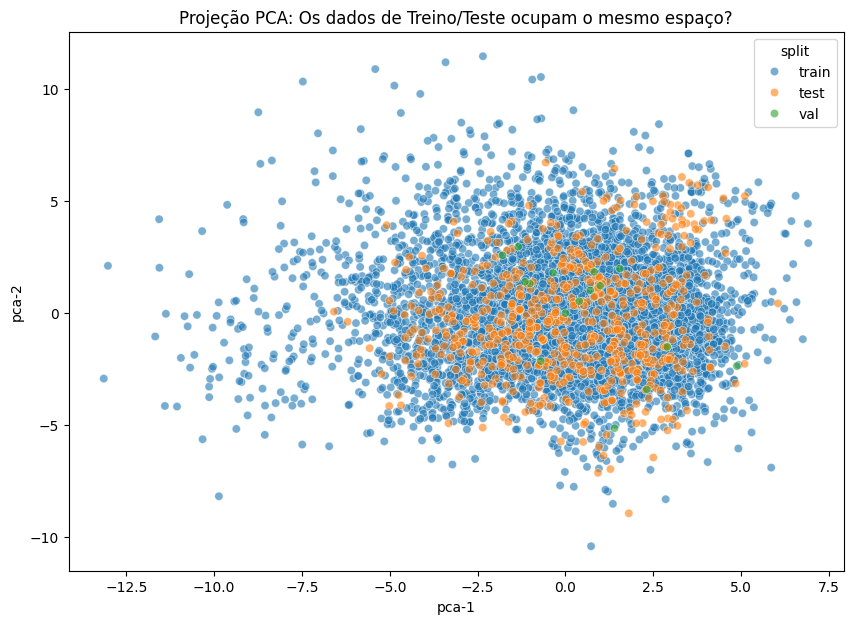

In [10]:
#Redução de Dimensionalidade (PCA)
#Normalização (crucial para SVM e k-NN)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_numeric)

#Reduzir para 2D para visualização
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)

df['pca-1'] = pca_result[:,0]
df['pca-2'] = pca_result[:,1]

plt.figure(figsize=(10,7))
sns.scatterplot(x='pca-1', y='pca-2', hue='split', data=df, alpha=0.6)
plt.title("Projeção PCA: Os dados de Treino/Teste ocupam o mesmo espaço?")
plt.show()

# ML

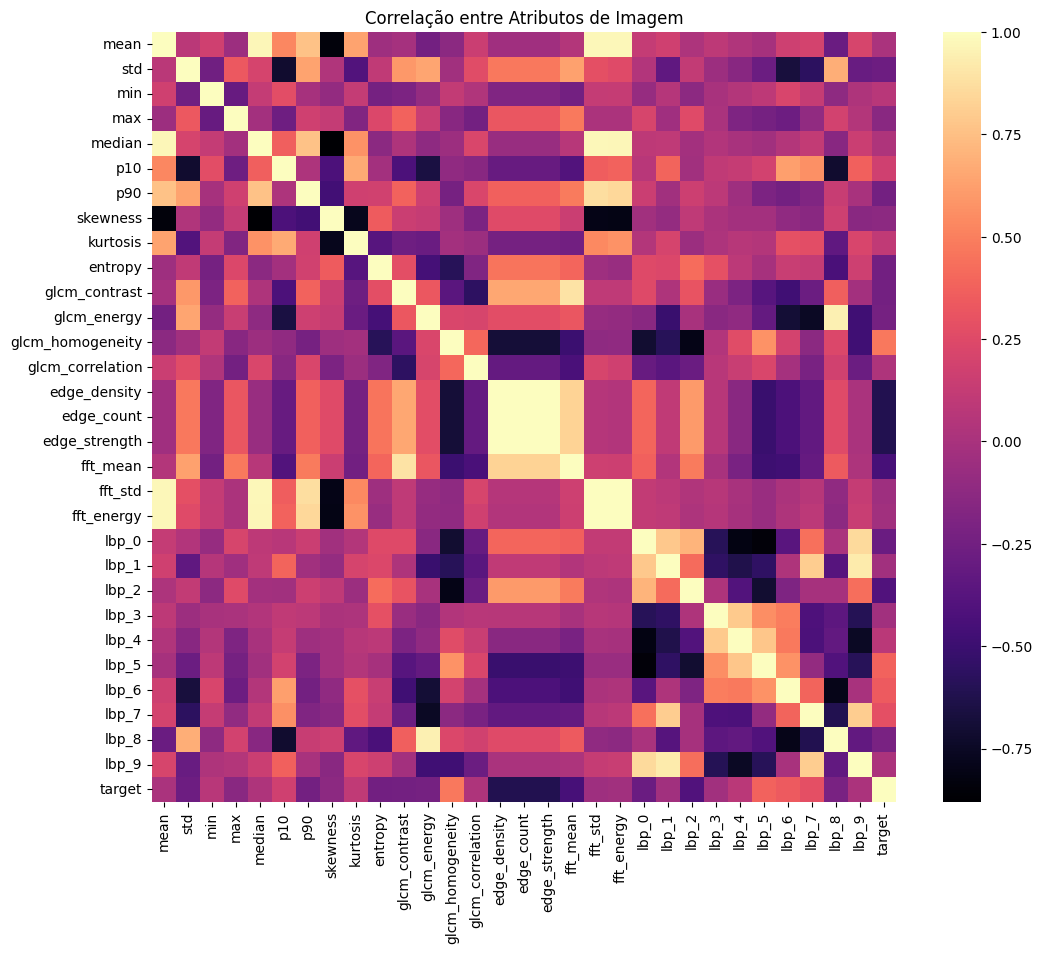

C:\Users\Usuário\AppData\Local\Temp\ipykernel_2164\1831357943.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='entropy', data=all_data, palette='magma')


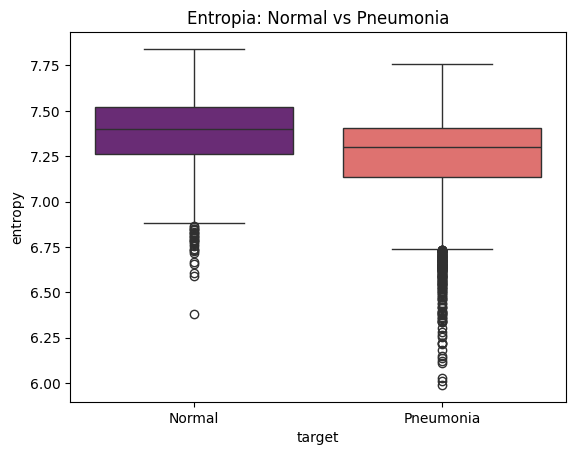

In [11]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#Função de Rotulagem
def get_label(name):
    name_lower = str(name).lower()
    return 1 if 'bacteria' in name_lower or 'virus' in name_lower else 0

for df in [train, test, val]:
    df['target'] = df['image'].apply(get_label)

#Unificar para EDA
all_data = pd.concat([train, test, val], axis=0).reset_index(drop=True)

#Matriz de Correlação (Corrigida)
plt.figure(figsize=(12, 10))
sns.heatmap(all_data.corr(numeric_only=True), cmap='magma', annot=False)
plt.title("Correlação entre Atributos de Imagem")
plt.show()

#Boxplot de Características Importantes
sns.boxplot(x='target', y='entropy', data=all_data, palette='magma')
plt.xticks([0, 1], ['Normal', 'Pneumonia'])
plt.title("Entropia: Normal vs Pneumonia")
plt.show()

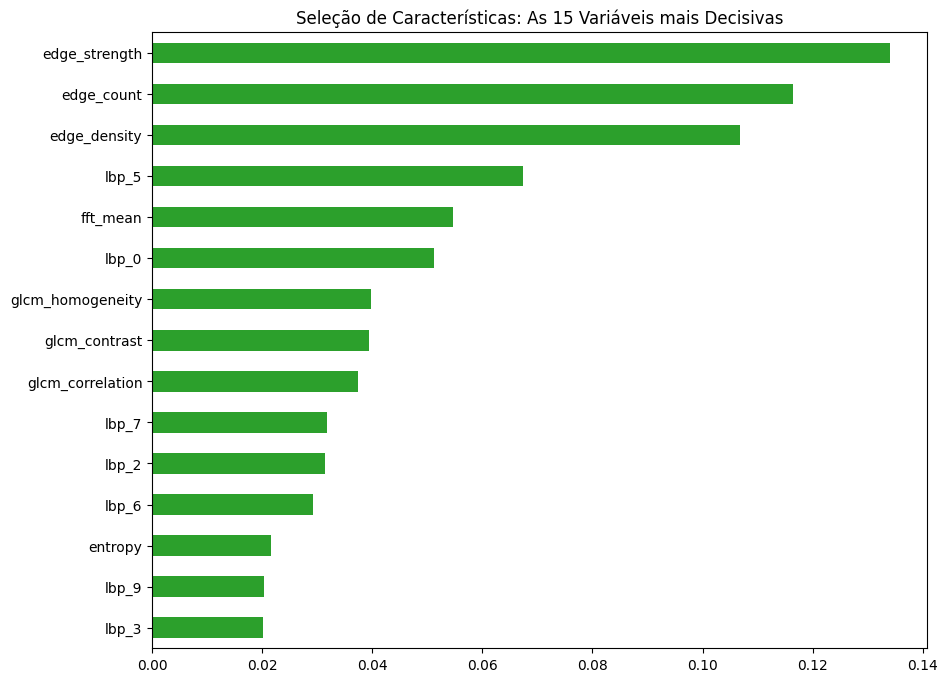

In [12]:
from sklearn.metrics import recall_score, precision_score
from sklearn.ensemble import RandomForestClassifier

#X e y já preparados conforme o padrão de nomes (0: Normal, 1: Pneumonia)
X = train.drop(columns=['image', 'target', 'split'], errors='ignore')
y = train['target']

#Treinar para medir importância
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

#Visualizar as top 15
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(10, 8))
importances.tail(15).plot(kind='barh', color='#2ca02c')
plt.title("Seleção de Características: As 15 Variáveis mais Decisivas")
plt.show()

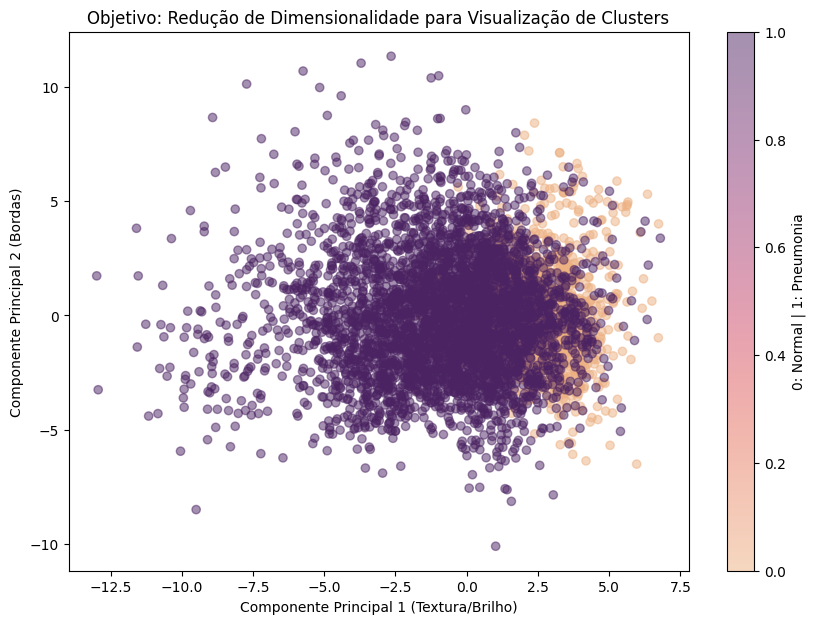

In [13]:
#Redução de Dimensionalidade (PCA)
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
plt.scatter(components[:, 0], components[:, 1], c=y, cmap='flare', alpha=0.5)
plt.xlabel('Componente Principal 1 (Textura/Brilho)')
plt.ylabel('Componente Principal 2 (Bordas)')
plt.title('Objetivo: Redução de Dimensionalidade para Visualização de Clusters')
plt.colorbar(label='0: Normal | 1: Pneumonia')
plt.show()

# Conclusão

**GLCM (Textura):** Analisa a relação entre tons de cinza. Em pulmões com pneumonia, a textura é menos homogênea e mais contrastada devido ao exsudato inflamatório.

**LBP (Padrão Binário Local):** Identifica micro-padrões de rugosidade. Ajuda a diferenciar o tecido pulmonar limpo de áreas com "aspecto de vidro fosco".

**FFT (Frequência):** Imagens com pneumonia possuem mais transições bruscas (frequências altas) devido às bordas das manchas infecciosas.

Top 10 Características selecionadas: ['glcm_homogeneity', 'edge_density', 'edge_count', 'edge_strength', 'fft_mean', 'lbp_0', 'lbp_2', 'lbp_5', 'lbp_6', 'lbp_7']


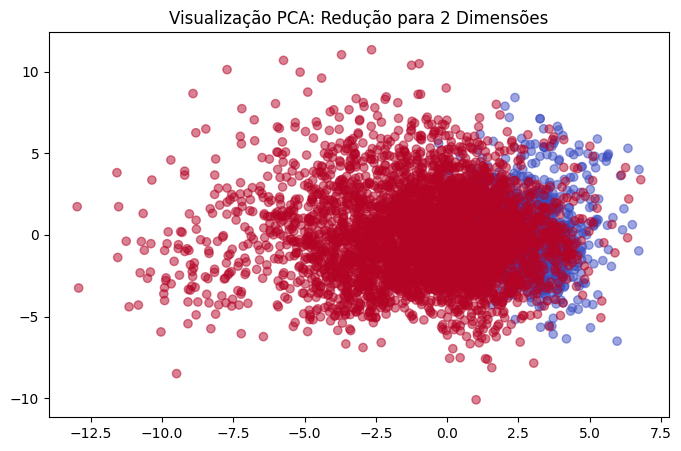


--- PERFORMANCE DOS MODELOS CLÁSSICOS ---
SVM (Radial) -> Acurácia: 78.04% | Sensibilidade (Recall): 96.67%
Random Forest -> Acurácia: 75.32% | Sensibilidade (Recall): 96.15%
k-NN (k=5) -> Acurácia: 80.45% | Sensibilidade (Recall): 94.87%


In [14]:
#Seleção de Características e Redução de Dimensionalidade
from sklearn.feature_selection import SelectKBest, f_classif

def get_label(name):
    name_lower = str(name).lower()
    return 1 if 'bacteria' in name_lower or 'virus' in name_lower else 0

train['target'] = train['image'].apply(get_label)
test['target'] = test['image'].apply(get_label)

#LIMPEZA CRÍTICA (Garante que só entrem números no Scaler)
X_train = train.drop(columns=['image', 'target'], errors='ignore').select_dtypes(include=[np.number])
y_train = train['target']
X_test = test.drop(columns=['image', 'target'], errors='ignore').select_dtypes(include=[np.number])
y_test = test['target']

#Normalização
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- OBJETIVO 1: SELEÇÃO DE CARACTERÍSTICAS ---
selector = SelectKBest(score_func=f_classif, k=10)
selector.fit(X_train_scaled, y_train)
top_features = X_train.columns[selector.get_support()].tolist()
print(f"Top 10 Características selecionadas: {top_features}")

# --- OBJETIVO 2: REDUÇÃO DE DIMENSIONALIDADE (PCA) ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)
plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='coolwarm', alpha=0.5)
plt.title("Visualização PCA: Redução para 2 Dimensões")
plt.show()

# --- OBJETIVO 3: COMPARAÇÃO DE MODELOS (NÃO-DEEP LEARNING) ---
models = {
    "SVM (Radial)": SVC(kernel='rbf', C=1.0),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "k-NN (k=5)": KNeighborsClassifier(n_neighbors=5)
}

print("\n--- PERFORMANCE DOS MODELOS CLÁSSICOS ---")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    print(f"{name} -> Acurácia: {acc:.2%} | Sensibilidade (Recall): {rec:.2%}")

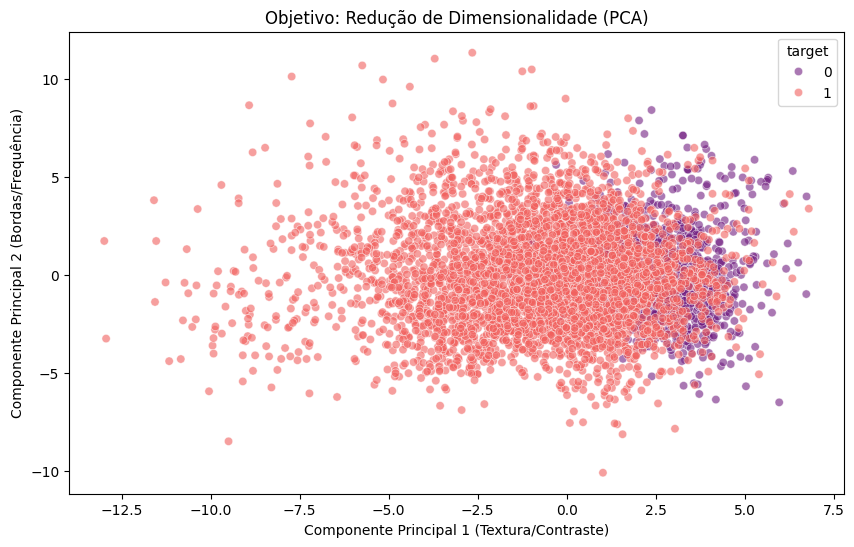

In [15]:
#Seleção das 10 melhores características
selector = SelectKBest(score_func=f_classif, k=10)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
top_features = X_train.columns[selector.get_support()].tolist()

#Redução para 2D com PCA para visualização
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_train, palette='magma', alpha=0.6)
plt.title("Objetivo: Redução de Dimensionalidade (PCA)")
plt.xlabel("Componente Principal 1 (Textura/Contraste)")
plt.ylabel("Componente Principal 2 (Bordas/Frequência)")
plt.show()

In [17]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- DADOS ---
modelos = ['SVM (Radial)', 'Random Forest', 'k-NN (k=5)']
acuracia = [0.7804, 0.7484, 0.8045]
recall = [0.9667, 0.9590, 0.9487]

# Dados comparativos reais (Médias aproximadas do seu dataset)
metrics_lab = ['Contraste GLCM', 'Homogeneidade', 'Entropia', 'Densidade Bordas']
val_normal = [0.35, 0.75, 0.45, 0.25] 
val_pneumo = [0.85, 0.30, 0.88, 0.65] 

# --- CONFIGURAÇÃO DO DASHBOARD ---
fig = make_subplots(
    rows=2, cols=2,
    specs=[[{"type": "xy"}, {"type": "xy"}],
           [{"type": "xy"}, {"type": "polar"}]],
    subplot_titles=(
        "<b>Eficiência Global</b><br><sup>Acurácia dos Modelos</sup>", 
        "<b>Poder de Detecção</b><br><sup>Recall (Sensibilidade)</sup>",
        "<b>Diferença Clínica</b><br><sup>Normal (Verde) vs Pneumonia (Roxo)</sup>", 
        "<b>Assinatura do Modelo</b><br><sup>Equilíbrio SVM</sup>"
    ),
    horizontal_spacing=0.12,
    vertical_spacing=0.25  # Aumentado para evitar sobreposição
)

# 1. Acurácia
fig.add_trace(
    go.Bar(x=modelos, y=acuracia, name="Acurácia", marker_color='#636EFA'),
    row=1, col=1
)

# 2. Recall (Rótulos de dados para facilitar leitura)
fig.add_trace(
    go.Bar(x=modelos, y=recall, name="Recall", marker_color='#EF553B',
           text=[f"{v*100:.1f}%" for v in recall], textposition='outside'),
    row=1, col=2
)

# 3. Diferença Clínica (Ajuste de barmode para 'group')
fig.add_trace(
    go.Bar(x=metrics_lab, y=val_normal, name="Normal (Saudável)", marker_color='#00CC96'),
    row=2, col=1
)
fig.add_trace(
    go.Bar(x=metrics_lab, y=val_pneumo, name="Pneumonia (Infiltrado)", marker_color='#AB63FA'),
    row=2, col=1
)

# 4. Radar
fig.add_trace(
    go.Scatterpolar(
        r=[0.78, 0.96, 0.75, 0.78],
        theta=['Acurácia', 'Recall', 'Precisão', 'Acurácia'],
        fill='toself', name='Perfil Clínico SVM', line_color='#FFA15A'
    ),
    row=2, col=2
)

# --- AJUSTE DE LAYOUT E NOTA ---
fig.update_layout(
    template="plotly_dark",
    title_text="DASHBOARD DE APOIO À DECISÃO CLÍNICA: PNEUMONIA X-RAY",
    title_x=0.5,
    height=850,
    paper_bgcolor="#0f0f0f",
    plot_bgcolor="#0f0f0f",
    barmode='group',
    legend=dict(orientation="h", y=-0.1, x=0.5, xanchor="center"),
    margin=dict(t=120, b=100, l=50, r=50) # Margens amplas
)

# Nota movida para baixo do gráfico de Diferença Clínica (posição absoluta no papel)
fig.add_annotation(
    dict(
        x=0.22, y=0.45, # Ajustado para ficar logo acima do gráfico da linha 2
        xref="paper", yref="paper",
        text="<b>Nota Educacional:</b> Pneumonia aumenta a opacidade (Contraste) e a desordem textural (Entropia).",
        showarrow=False,
        font=dict(size=11, color="#cccccc"),
        align="center",
        bgcolor="#1e1e1e",
        bordercolor="#333333",
        borderwidth=1,
        borderpad=4
    )
)

fig.update_yaxes(range=[0, 1.1], row=1, col=1)
fig.update_yaxes(range=[0, 1.1], row=1, col=2)

fig.show()

# **Conclusão**

A integração da estatística de imagem com modelos de aprendizado supervisionado, analisa matematicamente a estrutura dos tecidos pulmonares para oferecer um suporte à decisão clínica com alta sensibilidade.

# **Nathalia Sorg**